In [5]:
import serial
import serial.tools.list_ports
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import pandas as pd
plt.style.use('dark_background')

In [6]:
Ambit_Port = ""
Pulser_Port = ""
ports = serial.tools.list_ports.comports()
for port, desc, hwid in sorted(ports):
        if hwid[:4] == "USB ":
                print(f'Found USB devices:\t{hwid}')
                devices = hwid[4:].split(" ")
                if len(devices) > 1 and len(devices[0]) > 9:
                    if devices[0][-9:] == "1A86:55D4":
                        print(f'Ambit Likely at:\t{port}')
                        Ambit_Port = port
                    if devices[0][-9:] == "303A:1001":
                        print(f'Pulser Likely at:\t{port}')
                        Pulser_Port = port

if Ambit_Port == "": print(f'Ambit not Found')

if Pulser_Port == "": print(f'Pulser not Found')

Found USB devices:	USB VID:PID=1A86:55D4 SER=554C028532 LOCATION=1-4.2
Ambit Likely at:	COM10
Pulser not Found


In [7]:
def _readline(ser: serial.Serial, timeout: int):
    _t0 = time.time()
    s = ""
    while (time.time() - _t0 < timeout):
        if ser.in_waiting > 0:
            c = ser.read()
            if (c > bytes([0])) and (c < bytes([128])):
                if (c == b'\n') or (c == b'\r'):
                    if s == "":
                        pass
                    elif len(s) > 2:
                        return s
                else:
                    s += c.decode()
                
    return s

def _wait_for_line(ser: serial.Serial, target: str, input: str = "", timeout: float = 1.0, print_out = False):
    if input != "":
        ser.write((input + "\n").encode())
    t0 = time.time()
    timeout_t = t0 + timeout
    condition = False
    while (condition == False):
        _l = _readline(ser, 0.25)
        if target in _l:
            condition = True
        if print_out:
            if _l != "": print(_l)
        if time.time() > timeout_t:
            break

    return condition

    
def _parse_data_line(l:str)->dict:
    ret = {}
    if len(l) > 5:
        if (l[:2] == "T:") and ("," in l) and (":" in l):
            items = [n.split(':') for n in l.split(',') if ":" in n]
            for i in items:
                k = i[0]
                v = i[1]
                if len(k) > 0:
                    if v.isdecimal():
                        ret.update({k: int(v)})
                    if (v.count(".") == 1) and v.replace(".", "0").isdecimal():
                        ret.update({k: float(v)})

    return ret        


def Trigger(ser: serial.Serial) -> dict:
    ser.write(b"G")
    ser.flush()
    _ret = _parse_data_line(_readline(ser, .5))
    return _ret

def Ambit_actinic(ser: serial.Serial, v:int)->int:
    if (v > 255): return -1
    ser.write(bytes([65, v]))
    ser.flush()
    return v
    

def DAC_set(ser: serial.Serial, ch:int, v:int):
    ret = False
    if (ch == 2) or (ch == 4):
        if (v > -1) and (v < 4095):
            ret = _wait_for_line(ser, target = "Done", input = f'DAC,{ch},{v},\n', print_out=False)
    if ret == False: 
        print("DAC_set error", ch, v)
        return -1
    return v

def DAC_ONOFF(ser: serial.Serial, ch:int, onoff:bool):
    if onoff:
        if (ch == 2) or (ch == 4):
            _wait_for_line(ser, target = "Done", input = f'LED_ON,{ch},\n', print_out=False)
    else:
        if (ch == 2) or (ch == 4):
            _wait_for_line(ser, target = "Done", input = f'LED_OFF,{ch},\n', print_out=False)
        else:
            _wait_for_line(ser, target = "Done", input = f'LED_OFF,0,\n', print_out=False)

# plot autoscale
def autoscale(data: list, axis:plt.Axes):
    if len(data) == 0: return
    if len(data) == 1: 
        axis.set_ylim([data[0]-1, data[0]+1])
        return    
    l, h = axis.get_ylim()
    x, d = np.min(data), np.max(data)
    r = d - x

    _l, _h, a = l, h, False
    if (x < l) or (l < x - r):
        _l = x - 0.05 * r
        a = True
    if (d > h) or (h > l + r):
        _h = d + 0.05 * r
        a = True
    if a and _l != _h:
        axis.set_ylim([_l, _h])



In [25]:
ser.close()

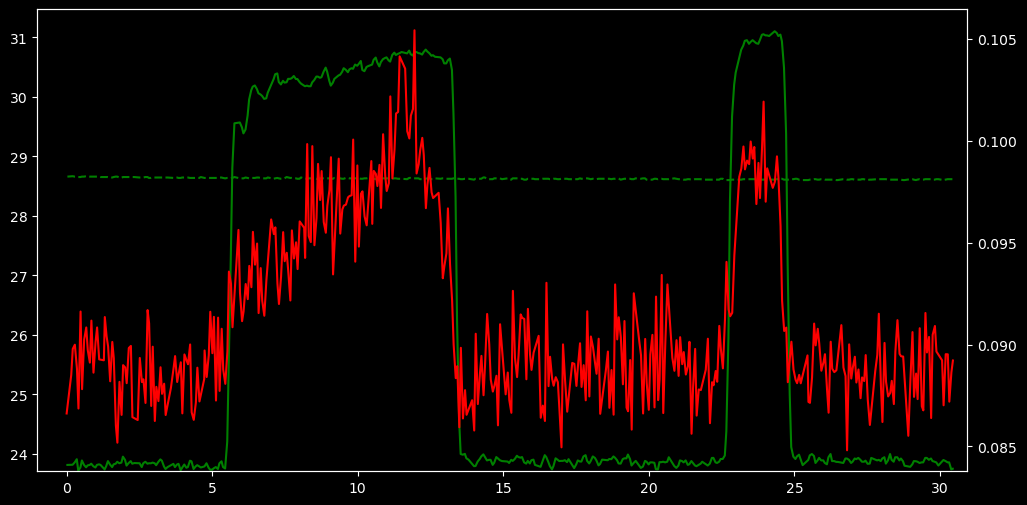

In [31]:
fig, axis = plt.subplots(1,1,figsize = (12,6))
ser = serial.Serial(Ambit_Port, 115200, rtscts=False) # This is Ambit

l1 = axis.plot([0], 'g')
l2 = axis.plot([0], 'g--')
ax = axis.twinx()
l3 = ax.plot([0], 'r')

START_TIME = time.time()
T1, S, R, F, B =  [], [], [], [], []
T2, Temp1, Temp2 = [], [], []
try:
    _wait_for_line(ser, target = "NEW Name", input = "hello", print_out=True)
    if not _wait_for_line(ser, target = "Start", input = "ww", print_out=True):
        ser.write(b'E\n')
        raise NameError("Function not started")
    
    if not _wait_for_line(ser, target = "Run", input = "", print_out=True):
        ser.write(b'E\n')
        raise NameError("Run not started") 
    plot_timer = 0
    while True:
        try:
            _ret = Trigger(ser)
            if _ret != {}: 
                T1.append(_ret['T']/1000)
                S.append(_ret['S']/_ret['R'])
                # R.append(_ret['R'])
                # F.append(_ret['F'])
                # B.append(_ret['B'])
                l3[0].set_xdata(T1)
                l3[0].set_ydata(S)
               

            ser.write(b"T")
            ser.flush()
            _ret = _parse_data_line(_readline(ser, .5))
            if _ret != {}: 
                T2.append(_ret['T']/1000)
                Temp1.append(_ret['o'])
                Temp2.append(_ret['a'])
                l1[0].set_xdata(T2)
                l2[0].set_xdata(T2)
                l1[0].set_ydata(Temp1)
                l2[0].set_ydata(Temp2)

            if time.perf_counter() - plot_timer > 1:                
                autoscale(S, ax)    
                autoscale(Temp1, axis)

                axis.set_xlim([-1, max(T1[-1], T2[-1]) + 1])
                display(fig)
                clear_output(True)
                plot_timer = time.perf_counter()

        except KeyboardInterrupt:
            break
    
    

finally:
    ser.write(b'E\n')
    ser.close()

In [19]:
T2

[23]

NEW Name Here Ready
Start
Run
Stop


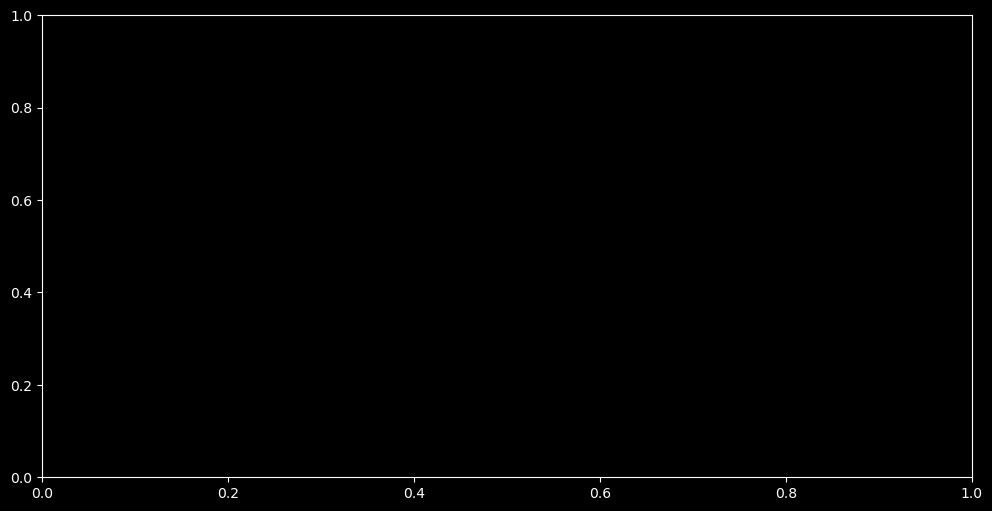

In [11]:
## This block run the protocol
# Change the protocol want to run:
run_protocol = Protocol_Eg1
# Signal offset when no exist
OFFSET = 4000
# Set the Serial ports for devices:
# If auto port detection doesn't work, put in Serial ports manually.

ser = serial.Serial(Ambit_Port, 115200, rtscts=False) # This is Ambit
try:
    ser_pulser = serial.Serial(Pulser_Port, 115200, dsrdtr= True, rtscts=False) # This is external LED
except:
    ser.close()
    raise ConnectionRefusedError
    





#
fig, axis = plt.subplots(1,1,figsize = (12,6))
START_TIME = time.time()
try:
    _wait_for_line(ser, target = "NEW Name", input = "hello", print_out=True)
    if not _wait_for_line(ser, target = "Start", input = "ww", print_out=True):
        ser.write(b'E\n')
        raise NameError("Function not started")
    
    if not _wait_for_line(ser, target = "Run", input = "", print_out=True):
        ser.write(b'E\n')
        raise NameError("Run not started")           


    _act_ambit, _act_blue, _act_red, act_blue, act_red = -1, -1, -1, 0, 0
    _data = []
    for _l in run_protocol:

        if _l[0] == 'M' and len(_l) == 4: # Run measurement
            
            if (_act_ambit != _l[3]):   # Set ambit actinic
                _act_ambit = Ambit_actinic(ser, _l[3])
            if (_l[1] < 1): continue    # no data
            for _ in range(_l[1]):
                _ts = time.perf_counter()
                _ret = Trigger(ser)
                if _ret != {}: 
                    _ret.update({"ACT":_act_ambit,"Blue":act_blue,"Red":act_red}.copy())
                    _data.append(_ret)
                _elapsed = time.perf_counter() - _ts
                if _elapsed < _l[2]: time.sleep(_l[2] - _elapsed)

        if _l[0] == 'A' and len(_l) == 3: # Change Actinic
            if _l[1] == "B":
                if _l[2] > 0:
                    if _act_blue != _l[2]: _act_blue = DAC_set(ser_pulser, 2, _l[2])
                    DAC_ONOFF(ser_pulser, 2, True)
                    act_blue = _act_blue
                else: 
                    DAC_ONOFF(ser_pulser, 2, False)
                    act_blue = 0
                
            if _l[1] == "R":
                if _l[2] > 0:
                    if _act_red != _l[2]: _act_red= DAC_set(ser_pulser, 4, _l[2])
                    DAC_ONOFF(ser_pulser, 4, True)
                    act_red = _act_red
                else: 
                    DAC_ONOFF(ser_pulser, 4, False)
                    act_red = 0
        

        if _l[0] == 'W' and len(_l) == 2:
            time.sleep(_l[1])

        if _l[0] == 'P':
            _plot_data = pd.DataFrame(_data)
            axis.clear()
            axis.plot(_plot_data['T']/1000, (_plot_data['S'] - OFFSET) / _plot_data['R'])
            display(fig)
            clear_output(True)
            


    

    DAC_ONOFF(ser_pulser, 0, False)
    Ambit_actinic(ser, 0)

    if not _wait_for_line(ser, target = "Stop", input = "E", print_out=True):
        ser.write(b'E\n')
        raise NameError("Run not Stopped")
    
finally:
    ser.close()
    ser_pulser.close()


data = pd.DataFrame(_data)
data.attrs['OFFSET'] = OFFSET
data.attrs['START_TIME'] = START_TIME
data.attrs['protocol'] = run_protocol

In [12]:
data.attrs

{'OFFSET': 4000,
 'START_TIME': 1738691730.8549724,
 'protocol': [['M', 100, 0.1, 0],
  ['M', 10, 0.1, 0],
  ['M', 250, 0.005, 254],
  ['M', 20, 0.01, 0],
  ['M', 20, 0.1, 0],
  ['M', 100, 0.1, 0]]}

In [14]:
data

,T,S,R,F,B,ACT,Blue,Red
0,5,7925,15539,2956,1549,0,0,0
1,103,8160,18395,1185,888,0,0,0
2,203,8189,19446,1043,868,0,0,0
3,304,8192,18595,1066,851,0,0,0
4,404,8205,18249,1081,842,0,0,0
...,...,...,...,...,...,...,...,...
492,24297,8479,18237,1523,836,0,0,0
493,24398,8489,18241,1444,836,0,0,0
494,24498,8466,18241,1365,832,0,0,0
495,24598,8486,18243,1373,840,0,0,0


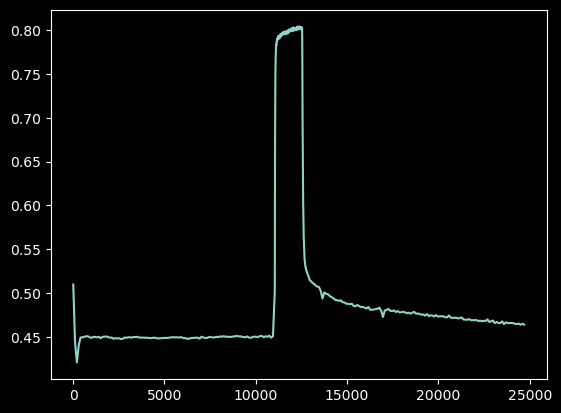

In [15]:
plt.plot(data['T'], data['S']/data['R'])